<a href="https://colab.research.google.com/github/swatidhoke/AI_AGENTS/blob/main/Student_Intro_to_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction to Machine Learning

### Objectives
 In this module, we aim to delve deeper into the intricacies of data analysis and machine learning techniques. Our primary objectives for this module are:

1. **Understand and Formulate Problem Statements**:
    - Grasp the nuances of formulating both regression and classification problem statements.
    - Tailor these problem statements specifically for the Titanic dataset.

2. **Implement Regression Techniques**:
    - Explore and implement linear regression to predict continuous variables such as passenger fare.
    - Interpret the results and visualize the regression model's performance.

3. **Explore Classification Techniques**:
    - Apply logistic regression classification algorithm to predict binary outcomes such as passenger survival.
    - Evaluate and visualize the performance of the classification model.

<center><img src="https://360digitmg.com/uploads/blog/Classification_vs_Regression.png"/></center>

## Section 1: A Quick Recap: Data Analysis (EDA) with the Titanic Dataset

1. **Introduction to the Titanic Dataset**:
    - We began with an overview of the Titanic dataset, which includes information about the passengers on the Titanic, such as their age, sex, class, fare, and survival status.

2. **Data Cleaning and Preprocessing**:
    - We addressed missing data, which is a common issue in real-world datasets. Techniques such as imputation and removal of null values were applied to handle missing data.
    - We transformed categorical variables into numerical ones using techniques like one-hot encoding, making the dataset suitable for analysis and modeling.

3. **Univariate Analysis**:
    - We conducted a detailed univariate analysis to understand the distribution of individual variables.
    - Visualizations such as histograms, bar plots, and box plots were used to illustrate the distributions and identify any anomalies or outliers.

4. **Bivariate Analysis**:
    - We explored relationships between pairs of variables to uncover any significant associations.
    - Techniques such as correlation analysis and scatter plots helped us identify potential predictors for our target variable, survival.

5. **Multivariate Analysis**:
    - We extended our analysis to multiple variables simultaneously, looking at how different factors interact and influence each other.
    - Heatmaps and pair plots were utilized to visualize these interactions and understand the complex relationships within the dataset.

6. **Feature Engineering**:
    - We created new features from existing data to enhance our analysis. For example, combining age and class to create an 'age_class' feature.
    - Feature engineering helped us uncover additional patterns and improve the performance of our models.

7. **Initial Insights and Findings**:
    - By the end of Module 1, we had gathered several key insights from our analysis. For example, we observed that women and children had higher survival rates compared to men.
    - These findings provided a strong foundation for building predictive models, which we will explore in this module.

The EDA performed in Module 1 has equipped us with a thorough understanding of the dataset and prepared us to tackle more advanced topics. With this foundation, we are ready to dive into regression and classification techniques in this class.

## Section 2: Data Preparation

#### New Libraries
    
1. **Scikit-learn (sklearn)**:
    - It includes simple and efficient tools for data mining and data analysis, such as algorithms for classification, regression, clustering, and more.
    - **Installation**: `pip install scikit-learn`
  
    
#### Data Preparation

Let's run the following code that loads the data and prepares it by performing the data cleaning, feature engineering steps performed earlier.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml

# Fetching the Titanic dataset from openml
titanic = sns.load_dataset('titanic')


# Preprocess the data
# Handle missing values
titanic['age'].fillna(titanic['age'].median(), inplace=True)
titanic['embarked'].fillna(titanic['embarked'].mode()[0], inplace=True)
titanic.dropna(subset=['embark_town'], inplace=True)

# Data type conversion
titanic['sex'] = titanic['sex'].astype('category')
titanic['embarked'] = titanic['embarked'].astype('category')
titanic['class'] = titanic['class'].astype('category')
titanic['who'] = titanic['who'].astype('category')
titanic['adult_male'] = titanic['adult_male'].astype('bool')
titanic['alone'] = titanic['alone'].astype('bool')

# Removing duplicates
duplicates = titanic.duplicated().sum()
if duplicates > 0:
    titanic = titanic.drop_duplicates()

# Treating fare outliers by capping
# Calculating IQR for 'Fare'
Q1 = titanic['fare'].quantile(0.25)
Q3 = titanic['fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
titanic['fare'] = titanic['fare'].apply(lambda x: upper_bound if x > upper_bound else (lower_bound if x < lower_bound else x))

# Treating age outliers by capping
# Calculating IQR for 'Age'
Q1 = titanic['age'].quantile(0.25)
Q3 = titanic['age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
titanic['age'] = titanic['age'].apply(lambda x: upper_bound if x > upper_bound else (lower_bound if x < lower_bound else x))


# Creating new feature 'Family_Size'
titanic['Family_Size'] = titanic['sibsp'] + titanic['parch'] + 1

# Creating new feature 'Is_Alone'
titanic['Is_Alone'] = (titanic['Family_Size'] == 1).astype(int)

# Creating new feature 'Fare_Per_Person'
titanic['Fare_Per_Person'] = titanic['fare'] / titanic['Family_Size']

# # Converting categorical features (4 columns) to numerical using one-hot encoding
df = pd.get_dummies(titanic, columns=['sex', 'embarked', 'class', 'who'], drop_first=True)

# Display the first few rows of the dataframe to verify loading
print("First few rows of the dataset:")
df.head()

First few rows of the dataset:


,survived,pclass,age,sibsp,parch,fare,adult_male,deck,embark_town,alive,...,Family_Size,Is_Alone,Fare_Per_Person,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman
0,0,3,22.0,1,0,7.250,True,NaN,Southampton,no,...,2,0,3.625,True,False,True,False,True,True,False
1,1,1,38.0,1,0,71.050,False,C,Cherbourg,yes,...,2,0,35.525,False,False,False,False,False,False,True
2,1,3,26.0,0,0,7.925,False,NaN,Southampton,yes,...,1,1,7.925,False,False,True,False,True,False,True
3,1,1,35.0,1,0,53.100,False,C,Southampton,yes,...,2,0,26.550,False,False,True,False,False,False,True
4,0,3,35.0,0,0,8.050,True,NaN,Southampton,no,...,1,1,8.050,True,False,True,False,True,True,False


## Section 3: Problem Statement Formulation

### Regression vs Classification
<center><img src="https://www.sharpsightlabs.com/wp-content/uploads/2021/04/regression-data-vs-classification-data.png" height=300 width=600/></center>

- Regression predicts a continuous numerical value as output based on various input features.
- Classification categorizes the data into a discrete class based on the input features.

<center><img src="https://cdn.careerfoundry.com/en/wp-content/uploads/old-blog-uploads/regression-vs--classification.jpg" width=600 height=300/></center>

### Formulating a Problem Statement for Regression and Classification

#### 1. Define the Objective:

- **Identify the end goal:** What is the ultimate outcome you want to predict?

- **Regression Example:** Predict the fare a passenger paid.

- **Classification Example:** Predict whether a passenger survived or not.

#### 2. Understand the Data:

- **Data Source:** Titanic dataset, which includes features like age, gender, passenger class, number of siblings/spouses, parents/children aboard, and fare.

- **Target Variable:** Identify what you are predicting.

- **Regression:** Continuous variable like `fare`.

- **Classification:** Categorical variable like `survived`.

#### 3. Define the Type of Problem:

##### Regression:
- **Problem Statement:** "Given the information about a passenger on the Titanic, such as their age, gender, class, number of siblings/spouses aboard, number of parents/children aboard, and port of embarkation, predict the fare that the passenger would have paid."

- **Why it’s a Regression Problem:** The target variable `fare` is continuous.

##### Classification:
- **Problem Statement:** "Given the characteristics of a passenger, such as age, gender, class, and number of family members aboard, predict whether the passenger survived the Titanic disaster."

- **Why it’s a Classification Problem:** The target variable `survived` is categorical (binary: 0 or 1).

## Section 5: Regression

<center><img src="https://miro.medium.com/v2/resize:fit:962/0*R2C2NeJzPKAdo_B-.jpg" width=500 height=300/></center>

To perform regression, we need to do the following on the dataset:
- Separate the dataset into features & target variable
- Standardize the features
- Split into training & testing data

<center><img src="https://www.machinelearningplus.com/wp-content/uploads/2022/12/train_test_split-procedure.jpg" width=600 height=300/></center>

#### What is standardization?
Standardization is a process used in data preprocessing to make sure that the features in a dataset have a consistent scale.

<center><img src="https://www.researchgate.net/publication/380320412/figure/fig1/AS:11431281240842588@1714787850736/Normalization-and-standardization.png" width=500 height=400/></center>



In [ ]:
# Display the column names to verify the structure of the dataset
print("Column names in the dataset:", df.columns)

Column names in the dataset: Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male',
       'deck', 'embark_town', 'alive', 'alone', 'Family_Size', 'Is_Alone',
       'Fare_Per_Person', 'sex_male', 'embarked_Q', 'embarked_S',
       'class_Second', 'class_Third', 'who_man', 'who_woman'],
      dtype='object')


Let's find out whether the variables(numerical columns) are correlated with the target variable - `fare`.

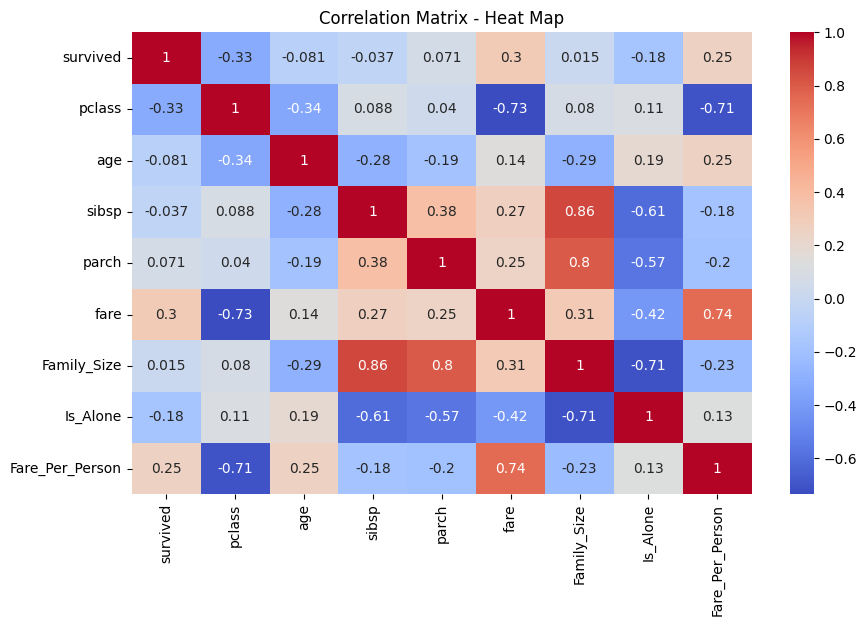

In [ ]:
# Correlation matrix - Heat Map
plt.figure(figsize=(10, 6))

# Select only numerical columns for correlation matrix
numerical_cols = titanic.select_dtypes(include=[np.number])
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix - Heat Map')
plt.show()

#### Observations: How are the features correlated with the target variable `fare`?
- There is a strong negative correlation with `pclass`, suggesting that passengers in higher classes (1st class) tend to pay more per person compared to those in lower classes.
- The positive correlation with `survived` indicating that passengers who paid a higher fare per person were more likely to survive, possibly reflecting the greater access to resources and lifeboats among wealthier passengers.
- The positive correlation between `Fare_Per_Person` and `age`, suggesting older passengers might have paid slightly more per person, potentially due to traveling alone or with fewer companions.
- The weak negative correlation with `Family_Size` indicates that larger families tend to have a slightly lower fare per person, as the fare is distributed among more members.


*Note: As `fare` is similar to `Fare_Per_Person` which is also indicated with the very high correlation value, let's not include `Fare_Per_Person` as the input feature for the prediction.

In [ ]:
# Select features and target variable for regression
features = ['pclass', 'age', 'sibsp', 'parch','Family_Size', 'Is_Alone','sex_male', 'embarked_Q', 'embarked_S',
      'class_Second', 'class_Third', 'who_man', 'who_woman','survived']
# Split the data into features (X) and target (y)
X = df[features]
#y = df['Fare_Per_Person']
y=df['fare']
X.head()

,pclass,age,sibsp,parch,Family_Size,Is_Alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman,survived
0,3,22.0,1,0,2,0,True,False,True,False,True,True,False,0
1,1,38.0,1,0,2,0,False,False,False,False,False,False,True,1
2,3,26.0,0,0,1,1,False,False,True,False,True,False,True,1
3,1,35.0,1,0,2,0,False,False,True,False,False,False,True,1
4,3,35.0,0,0,1,1,True,False,True,False,True,True,False,0


In [ ]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[ 0.88573331, -0.55891076,  0.4795023 , ...,  0.85955761,
        -0.68542784, -0.8371818 ],
       [-1.45717416,  0.66175883,  0.4795023 , ..., -1.16338915,
         1.45894279,  1.19448369],
       [ 0.88573331, -0.25374336, -0.53278034, ..., -1.16338915,
         1.45894279,  1.19448369],
       ...,
       [ 0.88573331, -0.10115966,  0.4795023 , ..., -1.16338915,
         1.45894279, -0.8371818 ],
       [-1.45717416, -0.25374336, -0.53278034, ...,  0.85955761,
        -0.68542784,  1.19448369],
       [ 0.88573331,  0.20400773, -0.53278034, ...,  0.85955761,
        -0.68542784, -0.8371818 ]])

#### Observation:
All features are now in the same scale. This will make the ML model more robust.

Now, the data has to be split into training & testing data.
- Training data is used for training the model to learn the patterns from the input features.
- Testing data is used to test whether the model has learnt properly in making predictions.

In [ ]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Display the first few rows of the prepared data
print("Training features:\n", X_train[:5])
print("Training target:\n", y_train[:5])
print("Testing features:\n", X_test[:5])
print("Testing target:\n", y_test[:5])

Training features:
 [[ 0.88573331 -1.62699665  3.51635023  0.69359849  2.66876547 -1.14224942
   0.77221207  3.49333506 -1.6248652  -0.5183914   0.96840639 -1.16338915
  -0.68542784 -0.8371818 ]
 [-0.28572042  0.35659143 -0.53278034 -0.49914593 -0.62178265  0.87546554
   0.77221207 -0.2862594   0.61543567  1.92904435 -1.03262433  0.85955761
  -0.68542784 -0.8371818 ]
 [ 0.88573331 -0.7877863  -0.53278034 -0.49914593 -0.62178265  0.87546554
   0.77221207  3.49333506 -1.6248652  -0.5183914   0.96840639  0.85955761
  -0.68542784 -0.8371818 ]
 [-0.28572042 -0.94037    -0.53278034 -0.49914593 -0.62178265  0.87546554
  -1.29498106 -0.2862594  -1.6248652   1.92904435 -1.03262433 -1.16338915
   1.45894279  1.19448369]
 [-0.28572042 -0.63520261 -0.53278034 -0.49914593 -0.62178265  0.87546554
  -1.29498106 -0.2862594   0.61543567  1.92904435 -1.03262433 -1.16338915
   1.45894279  1.19448369]]
Training target:
 787    29.125
722    13.000
143     6.750
389    12.000
56     10.500
Name: fare, dtyp

#### Implementation of Linear Regression Model

The following tasks need to be performed for the model implementation:
- Imports necessary libraries.
- Initializes and fits a linear regression model.
- Makes predictions on the test data.
- Evaluates the model using various metrics.
- Displays the model's coefficients and intercept.

In [ ]:
# Import necessary libraries for Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Initialize the Linear Regression model
lr_model = LinearRegression()

# Fit the model to the training data
lr_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = lr_model.predict(X_test)

y_pred

array([ 5.59051916,  5.37469885,  5.37469885, 25.4020426 , 29.32616544,
        5.83758948,  6.3617066 , 21.67021239, 56.47626135,  9.52508948,
       19.4250952 , 17.53710294, 63.00389982,  5.0661051 ,  4.20282385,
       16.32362066, 57.43554044, 22.13934729,  5.93036291, 25.1520426 ,
       43.74022794, 16.4254801 , 10.18163419,  6.3617066 , 44.49549566,
       59.78748785, 45.52050138, 61.40038419, 20.97401128, 19.21717535,
        5.12762854,  5.86786291, 25.5348551 , 50.19080816, 51.58788419,
       65.66210294,  6.62665198, 17.10741544,  4.94305823,  5.80633948,
       48.52606604, 47.37206388,  6.85584722,  5.34344885,  5.31317541,
       31.19364989, 57.68163419, 44.12537847,  6.54725347,  5.86786291,
        4.69598791,  5.12762854, 33.24969885, 54.06512854, 13.8004801 ,
       13.82030607,  6.62665198,  5.99188635, 19.15565191, 42.0895426 ,
       29.9957926 , 47.41571448, 20.8082926 , 12.0895426 , 63.00389982,
        4.63446448, 23.18944669, 50.90917326,  5.37469885, 10.44

#### How to check whether the model has learnt well to do accurate predictions?
Model Evaluation.

<center><img src="https://miro.medium.com/v2/resize:fit:586/1*8B-BYuBQ0ZYra0nMAuhV5w.png" width=400 height=400/></center>

There are various errors and the goal is to minimize the error.
<center><img src="https://miro.medium.com/v2/resize:fit:1200/1*rVTCIffI2D_-i_CGeHwF6A.png" width=600 height=400/></center>

In [ ]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print("Linear Regression Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")



Linear Regression Model Evaluation:
Mean Absolute Error (MAE): 7.646450250765044
Mean Squared Error (MSE): 129.7897626170439
R-squared (R2): 0.7351411293051022


#### Interpretation of Model Evaluation Metrics:

- **1. Mean Absolute Error (MAE): 7.65**
On average, the model's predictions deviate from the actual `fare` values by approximately 7.65 units (currency units in this context). This reflects the average magnitude of errors in predictions, without considering their direction.

- **2. Mean Squared Error (MSE): 129.79**
The MSE measures the average of the squared differences between the predicted and actual values, emphasizing larger errors due to the squaring effect. An MSE of 129.79 indicates the variance of errors, with larger errors contributing more to the MSE.

- **3. R-squared (R2): 0.735**
The R² value of 0.735 suggests that approximately 73.5% of the variance in the `fare` can be explained by the model’s features. This indicates a good fit, meaning the model captures a significant portion of the variability in the target variable.

### Visualization of Linear Regression Metrics


These visualizations will provide insights into the strengths and weaknesses of the Linear Regression model, highlighting areas for potential improvement.

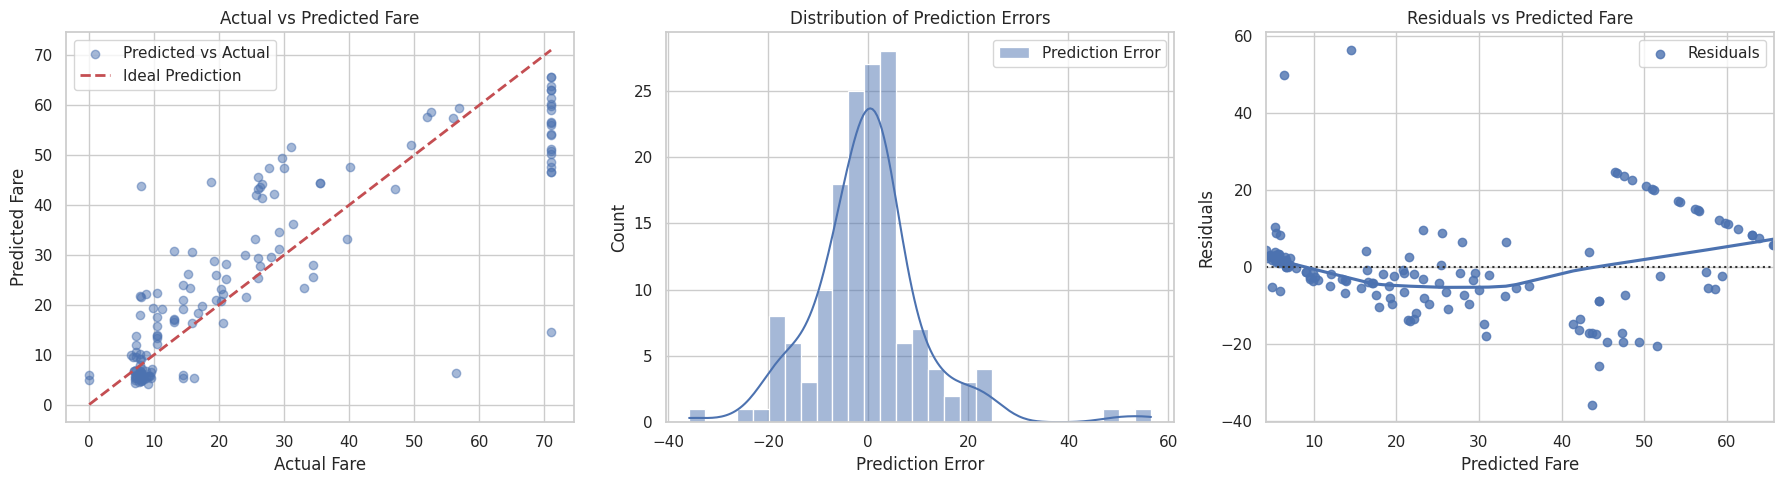

In [ ]:
#Visualization of Regression Predictions

import matplotlib.pyplot as plt
import seaborn as sns

# Set style for seaborn
sns.set(style="whitegrid")

# Create a figure with multiple subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot of actual vs predicted fares
axes[0].scatter(y_test, y_pred, alpha=0.5, label='Predicted vs Actual')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2, label='Ideal Prediction')
axes[0].set_xlabel('Actual Fare')
axes[0].set_ylabel('Predicted Fare')
axes[0].set_title('Actual vs Predicted Fare')
axes[0].legend()

# Distribution plot of prediction errors
errors = y_test - y_pred
sns.histplot(errors, kde=True, ax=axes[1], label='Prediction Error')
axes[1].set_xlabel('Prediction Error')
axes[1].set_title('Distribution of Prediction Errors')
axes[1].legend()

# Residual plot
sns.residplot(x=y_pred, y=errors, lowess=True, ax=axes[2], label='Residuals')
axes[2].set_xlabel('Predicted Fare')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals vs Predicted Fare')
axes[2].legend()

# Adjust layout
plt.tight_layout()
plt.show()


### Interpretation of the Results:

#### Graph 1: Actual vs Predicted Fare

- The model shows a generally good trend, where higher actual fares correspond to higher predicted fares.
- Most predictions are close to the ideal line, indicating that the model is fairly accurate for many data points.
- **Flaw:** There is a noticeable deviation from the ideal line, especially at higher fares, indicating that the model struggles with predicting higher fare values accurately.

#### Graph 2: Distribution of Prediction Errors

- The majority of prediction errors are close to zero, showing that the model makes mostly accurate predictions.
- The error distribution being centered around zero suggests that the model does not consistently overpredict or underpredict.
- **Flaw:** The right-skewed distribution indicates that the model tends to underpredict fares more frequently, suggesting a potential bias.

#### Graph 3: Residuals vs Predicted Fare

- The model captures the general trend, with most residuals being small around lower predicted fares.
- The residuals around lower predicted fares are close to zero, indicating the model is quite accurate in this range.
- **Flaw:** The increasing spread of residuals with higher predicted fares and the visible pattern suggest the model may not fully capture the complexity of the data, indicating possible issues with non-linearity or heteroscedasticity.

### How to improve this model?
- Introduce interaction terms and polynomial features to capture non-linear relationships between variables.
- Apply regularization techniques like Ridge or Lasso regression to address multicollinearity and improve model generalization.
- Consider using non-linear models such as Random Forests or Gradient Boosting for better performance on complex data.
- Use cross-validation and hyperparameter tuning to optimize model performance and prevent overfitting.
- Address potential issues with heteroscedasticity and outliers through appropriate transformations and weighted regression techniques.

*Note: You will gradually learn the above mentioned techniques gradually throughout the course.*

<hr> <hr>

## Section 6: Classification

<center><img src="https://media.licdn.com/dms/image/v2/D5612AQGzX1I9U8g0zg/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1706192358930?e=2147483647&v=beta&t=a5XI7FlCMnwr2fuPMuucnLsTh37UZW5lH6oYO38s9tg" width=600 height=300/></center>

There are various algorithms to perform classification. A few are as follows:
- Logistic Regression
- kNN
- Naive Bayes
- SVM
- Decision Trees
- Random Forest

*Note: You will learn about these classifiers gradually throughout this course.*

#### Logistic Regression
- Logistic regression is used to predict a binary outcome (e.g., yes/no, 0/1) based on input features.
- It uses the logistic function (or sigmoid curve) to map predicted values to probabilities between 0 and 1.
- If the predicted probability is above a certain threshold (typically 0.5), the model classifies the instance as 1 (e.g., "yes"); otherwise, it classifies it as 0 (e.g., "no").
<center><img src="https://miro.medium.com/v2/resize:fit:1000/1*vC--ianl5Ua7hQjnivYUww.png" width=400 height=300/></center>
- During training, the model adjusts the weights of the features to best fit the training data, minimizing the difference between predicted probabilities and actual outcomes.


#### Steps:

Follow the same preprocessing steps followed for regression.

Now, for classification, the target variable is the `Survived` column. Accordingly, the feature and target separation has to be done.

In [ ]:
# Select features and target variable for classification
features = ['pclass', 'age', 'sibsp', 'parch','fare','Fare_Per_Person','Family_Size', 'Is_Alone','sex_male', 'embarked_Q', 'embarked_S',
       'class_Second', 'class_Third', 'who_man', 'who_woman']
target = 'survived'

# Split the data into features (X) and target (y)
X = df[features]
y = df[target]

# Display the first 5 rows of the features data
X.head()

,pclass,age,sibsp,parch,fare,Fare_Per_Person,Family_Size,Is_Alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman
0,3,22.0,1,0,7.250,3.625,2,0,True,False,True,False,True,True,False
1,1,38.0,1,0,71.050,35.525,2,0,False,False,False,False,False,False,True
2,3,26.0,0,0,7.925,7.925,1,1,False,False,True,False,True,False,True
3,1,35.0,1,0,53.100,26.550,2,0,False,False,True,False,False,False,True
4,3,35.0,0,0,8.050,8.050,1,1,True,False,True,False,True,True,False


In [ ]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Display the first few rows of the prepared data
print("Training features:\n", X_train[:5])
print("Training target:\n", y_train[:5])
print("Testing features:\n", X_test[:5])
print("Testing target:\n", y_test[:5])

Training features:
 [[ 0.88573331 -1.62699665  3.51635023  0.69359849  0.13677592 -0.73459772
   2.66876547 -1.14224942  0.77221207  3.49333506 -1.6248652  -0.5183914
   0.96840639 -1.16338915 -0.68542784]
 [-0.28572042  0.35659143 -0.53278034 -0.49914593 -0.59327408 -0.20485111
  -0.62178265  0.87546554  0.77221207 -0.2862594   0.61543567  1.92904435
  -1.03262433  0.85955761 -0.68542784]
 [ 0.88573331 -0.7877863  -0.53278034 -0.49914593 -0.87623919 -0.61130631
  -0.62178265  0.87546554  0.77221207  3.49333506 -1.6248652  -0.5183914
   0.96840639  0.85955761 -0.68542784]
 [-0.28572042 -0.94037    -0.53278034 -0.49914593 -0.6385485  -0.26988394
  -0.62178265  0.87546554 -1.29498106 -0.2862594  -1.6248652   1.92904435
  -1.03262433 -1.16338915  1.45894279]
 [-0.28572042 -0.63520261 -0.53278034 -0.49914593 -0.70646013 -0.36743319
  -0.62178265  0.87546554 -1.29498106 -0.2862594   0.61543567  1.92904435
  -1.03262433 -1.16338915  1.45894279]]
Training target:
 787    0
722    0
143    0
3

#### Implementation of Logistic Regression

This code block performs the following tasks:
- Imports necessary libraries.
- Initializes and fits a logistic regression model.
- Makes predictions on the test data.
- Evaluates the model using various metrics.
- Displays the evaluation results, including accuracy and classification metrics.


In [ ]:
#Implementation of Logistic Regression

# Import necessary libraries for Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the Logistic Regression model
logistic_model = LogisticRegression()

# Fit the model on the training data
logistic_model.fit(X_train, y_train)

# Predict on the testing set
y_pred = logistic_model.predict(X_test)

y_pred

array([0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0])

#### How to find whether the model has learnt well to make accurate classifications?

Model Evaluation.

#### Confusion Matrix:
A confusion matrix is a table used to evaluate the performance of a classification model by showing the counts of true positives, true negatives, false positives, and false negatives.
<center><img src="https://miro.medium.com/v2/resize:fit:552/1*iRT_2S0F7X9zqC8gsCKyfA.png" width =400 height=300/>
<img src=" https://miro.medium.com/v2/resize:fit:974/1*H_XIN0mknyo0Maw4pKdQhw.png" width=500 height=300/></center>

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Display the evaluation results
print("Accuracy of Logistic Regression model:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)


Accuracy of Logistic Regression model: 0.7884615384615384
Confusion Matrix:
 [[82  8]
 [25 41]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.91      0.83        90
           1       0.84      0.62      0.71        66

    accuracy                           0.79       156
   macro avg       0.80      0.77      0.77       156
weighted avg       0.80      0.79      0.78       156



#### Interpretation of Logistic Regression Results

1. **Accuracy**:
   - The model has an accuracy of approximately 78.8%, meaning it correctly classifies around 79% of the instances.

2. **Confusion Matrix**:
   - The confusion matrix is as follows:
     ```
     [[A  B]
      [ C  D]]
     ```
  - **True Negatives (TN):** `A` passengers who did not survive were correctly predicted as not surviving.
  - **False Positives (FP):** `B` passengers who did not survive were incorrectly predicted as survivors.
  - **False Negatives (FN):** `C` passengers who survived were incorrectly predicted as not surviving.
  - **True Positives (TP):** `D` passengers who survived were correctly predicted as survivors.

  
3. **Classification Report**:
  
  The classification report provides detailed metrics to evaluate the performance of the model for each class, which are summarized below:

  - **Class 0 (Not Survived):**
    - **Precision:** 0.77, meaning 77% of passengers predicted as not surviving were correctly classified.
    - **Recall:** 0.91, indicating that the model successfully identified 91% of the actual non-survivors.
    - **F1-Score:** 0.83, which is a balanced measure of precision and recall, showing that the model performs well in predicting passengers who did not survive.

  - **Class 1 (Survived):**
    - **Precision:** 0.84, meaning 84% of passengers predicted as surviving were correctly classified as survivors.
    - **Recall:** 0.62, indicating that the model correctly identified 62% of actual survivors, highlighting some room for improvement in capturing all survivors.
    - **F1-Score:** 0.71, which reflects a moderate balance between precision and recall for predicting survivors, suggesting the model is fairly good but has potential for enhancement in this area.

4. **Macro and Weighted Averages**:
  - **Macro Average:**
  Both classes are treated equally, resulting in a precision, recall, and F1-score of 0.80, 0.77, and 0.77, respectively.
  - **Weighted Average:**
  Takes into account the support (number of true instances) for each class, leading to an F1-score of 0.78, indicating overall model performance.


#### Overall Model Performance:
- The model performs better in predicting non-survivors (Class 0) than survivors (Class 1), with higher recall and F1-score for Class 0. While the precision for predicting survivors is high, the lower recall for Class 1 suggests that the model misses a significant number of actual survivors, indicating an area for potential improvement.

### Visualization of Logistic Regression Metrics


These visualizations will provide insights into the strengths and weaknesses of the Logistic Regression model, highlighting areas for potential improvement.

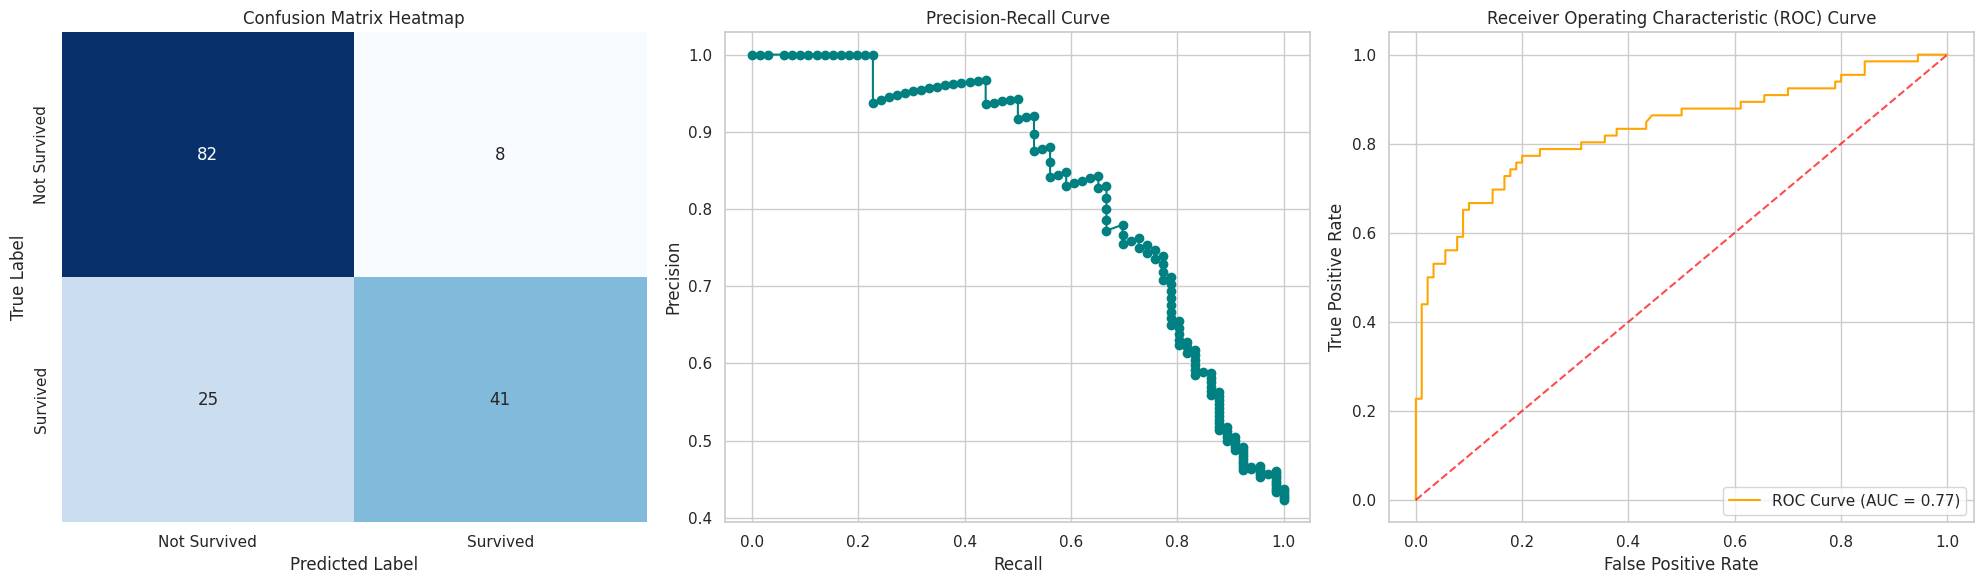

In [ ]:
# Make predictions and ensure y_pred is in integer format
y_pred = logistic_model.predict(X_test).astype(int)  # Ensure y_pred is integers

# Convert y_test to integers if they are strings (in case this is needed)
y_test = y_test.astype(int)

# Import necessary libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score

# Set the style for the plots
sns.set(style="whitegrid")

# Create a figure with a larger size for better readability
plt.figure(figsize=(20, 6))

# 1. Confusion Matrix Heatmap
plt.subplot(1, 3, 1)  # 1 row, 3 columns, first subplot
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'], cbar=False)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# 2. Precision-Recall Curve
plt.subplot(1, 3, 2)  # 1 row, 3 columns, second subplot
precision, recall, _ = precision_recall_curve(y_test, logistic_model.predict_proba(X_test)[:, 1])
plt.plot(recall, precision, marker='o', color='teal')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)

# 3. ROC Curve
plt.subplot(1, 3, 3)  # 1 row, 3 columns, third subplot
fpr, tpr, _ = roc_curve(y_test, logistic_model.predict_proba(X_test)[:, 1])
roc_auc = roc_auc_score(y_test, y_pred)
plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.2f})'.format(roc_auc), color='orange')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', alpha=0.7)
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


### Interpretation of the Visualizations:

#### Precision-Recall Curve
- **Purpose**: The precision-recall curve is used to visualize the trade-off between precision and recall for different threshold settings of the model.
- **Analysis**:
  - The Precision-Recall curve shows that as recall increases, precision decreases, highlighting the trade-off between identifying more true positives and maintaining accuracy.
  - Initially, the model exhibits high precision at lower recall levels, suggesting it is confident in its early predictions.


#### ROC Curve and AUC

- **Purpose**: The Receiver Operating Characteristic (ROC) curve visualizes the performance of a binary classifier as its discrimination threshold is varied. The Area Under the ROC Curve (AUC) provides a single measure of overall model performance.
- **Analysis**:
  - The ROC curve with an AUC of 0.77 indicates the model has a good, but not perfect, ability to distinguish between survivors and non-survivors.
  - The ROC curve is above the diagonal, demonstrating that the model performs better than random guessing.
  - Overall, the model shows a balanced performance but could be improved to achieve higher precision and a better AUC score.

These visualizations and metrics provide a comprehensive understanding of the Logistic Regression model's performance. The confusion matrix helps identify the types of errors the model makes, while the precision-recall and ROC curves provide insights into the trade-offs between different performance metrics. The AUC value indicates the overall effectiveness of the model in distinguishing between passengers who survived and those who did not.

<hr><hr>

## What Next?

We will explore more classification algorithms in the next class.